# Rbio Demo: Dual-Task LLM Post-Training Experiment

<a target="_blank" href="https://colab.research.google.com/github/raphaelrubrice/rbio/blob/main/rbio_colab_dual_experiment.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

**Google Colab Note:** It is strongly recommended to run this notebook with an A100 GPU, which is only included with Google Colab Pro or Enterprise paid services.
Alternatively, a "pay as you go" option is available. See [Colab Service Plans](https://colab.research.google.com/signup) for details.

**Heavily inspired by rbio1's initial colab notebook: https://colab.research.google.com/drive/14pCqM1W84rglo8_-GT5PRtKlI7eMvM3j**

## Learning Goals

This notebook extends the base Rbio demo by comparing **standard GRPO training** against **dual-task GRPO training**, each run 5 times with different random seeds.

**What you will do:**
1. Set up the full Rbio environment on Colab, including PerturbQA knowledge graphs.
2. Train the LLM **without** the dual task (5 seeds) and collect reward curves + held-out accuracy.
3. Train the LLM **with** the dual task (5 seeds) and collect the same metrics.
4. Visualize results with seaborn and export plots as PNG files.

---

## Pre-requisites
* **GPU**: A100 recommended. T4 is possible with a smaller model.
* **Libraries**: numpy, pandas, torch, datasets, transformers, trl, accelerate, seaborn.

## Introduction

Rbio post-trains an LLM using a soft verification signal from a simplified Virtual Cell Model (VCM). This notebook adds a **dual task**: after predicting whether gene A affects gene B, the model is asked to identify gene B from a candidate list given knowledge-graph context. This second task acts as an additional grounding signal during training.

See the [preprint](https://www.biorxiv.org/content/10.1101/2025.08.18.670981v3) and the [PerturbQA dataset](https://github.com/genentech/PerturbQA) for full details.

# Setup

### Setup Google Colab

Choose the A100 runtime from the "Connect" dropdown in the upper-right corner before running any cells.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### **IMPORTANT: Set an `OUTPUT_DIR` secret to save your analysis plots.**
We will load it later as an environment variable.

## Download necessary assets

In [2]:
!pip install gdown -q

In [3]:
!git clone https://github.com/raphaelrubrice/rbio.git /content/rbio

Cloning into '/content/rbio'...
remote: Enumerating objects: 278, done.
remote: Counting objects: 100% (154/154), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 278 (delta 103), reused 87 (delta 46), pack-reused 124 (from 1)
Receiving objects: 100% (278/278), 7.67 MiB | 12.74 MiB/s, done.
Resolving deltas: 100% (168/168), done.


## Download MLP checkpoint and ESM embeddings

In [4]:
# Download embeddings
!gdown "https://drive.google.com/uc?id=1hBhnanbna2t5TBZlhPr6Y8sPZbOX_BV9"

# Download MLP checkpoint
!gdown "https://drive.google.com/uc?id=1o6FvLUGlFz8f-vYrhc1shAYVxtGNQEkh"

Downloading...
From (original): https://drive.google.com/uc?id=1hBhnanbna2t5TBZlhPr6Y8sPZbOX_BV9
From (redirected): https://drive.google.com/uc?id=1hBhnanbna2t5TBZlhPr6Y8sPZbOX_BV9&confirm=t&uuid=6528f32e-fa4a-4152-952f-344b9233937a
To: /content/esm_embedding_dictionary_filled.pkl
100% 112M/112M [00:00<00:00, 115MB/s]
Downloading...
From: https://drive.google.com/uc?id=1o6FvLUGlFz8f-vYrhc1shAYVxtGNQEkh
To: /content/mlp_model.pt
100% 1.31M/1.31M [00:00<00:00, 165MB/s]


## Download training data

In [5]:
!gdown "https://drive.google.com/uc?id=16WR4a4bdqiWXd72HToFvAJ66e1jxsp-k"

Downloading...
From: https://drive.google.com/uc?id=16WR4a4bdqiWXd72HToFvAJ66e1jxsp-k
To: /content/k562-train-v0.3.0.csv
100% 81.5M/81.5M [00:00<00:00, 217MB/s]


## Download PerturbQA data (KG + gene summaries)

KG and gene summary data are hosted on Google Drive. Downloads ~400 MB total.

In [6]:
!python /content/rbio/PerturbQA/download_data.py
print("PerturbQA setup complete.")
!ls /content/rbio/PerturbQA

Downloading...
From (original): https://drive.google.com/uc?id=1czfVavbkkZFBNLYMCRIICh2Czr-LOfSU
From (redirected): https://drive.google.com/uc?id=1czfVavbkkZFBNLYMCRIICh2Czr-LOfSU&confirm=t&uuid=a8c7155b-c2bc-4909-aa64-9fe46ba6ee9b
To: /content/rbio/PerturbQA/kg.zip
100% 46.1M/46.1M [00:00<00:00, 142MB/s]
  Extracting → /content/rbio/PerturbQA/kg/
Downloading...
From: https://drive.google.com/uc?id=1sdh14LnF3unPWZiTmYYOMN29FH3McIUX
To: /content/rbio/PerturbQA/gene_summary.zip
100% 6.42M/6.42M [00:00<00:00, 76.0MB/s]
  Extracting → /content/rbio/PerturbQA/gene_summary/
Traceback (most recent call last):
  File "/content/rbio/PerturbQA/download_data.py", line 77, in <module>
    main()
  File "/content/rbio/PerturbQA/download_data.py", line 58, in main
    shutil.move(dest / "perturbqa" / "datasets" / "kg", dest)
  File "/usr/lib/python3.12/shutil.py", line 845, in move
    raise Error("Destination path '%s' already exists" % real_dst)
shutil.Error: Destination path '/content/rbio/Pertu

## Set up directories

## Download PerturbQA data (KG + gene summaries)

Uses `PerturbQA/download_data.py` from the cloned repo to fetch KG and gene summaries
from Google Drive. Downloads ~400 MB total.

## Install dependencies

In [7]:
import os
os.environ["WANDB_DISABLED"] = "true"
os.environ["DISABLE_MLFLOW_INTEGRATION"] = "true"
os.environ["TRANSFORMERS_NO_TORCHVISION"] = "1"
os.environ["TRANSFORMERS_IMAGE_TRANSFORMS"] = "0"

In [8]:
!pip install -q uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 110.4 MB/s eta 0:00:00


In [9]:
!uv pip uninstall torchvision torchaudio torch -q
!uv pip install --no-cache-dir --index-url https://download.pytorch.org/whl/cu124 \
  torch==2.6.0 torchaudio==2.6.0 -q
!uv pip install --no-cache-dir \
  transformers==4.51.3 trl==0.16.1 datasets==3.5.0 \
  pandas==2.2.3 "protobuf>=4.25" accelerate tiktoken seaborn -q
!uv pip install --no-cache-dir liger-kernel==0.6.5 -q


In [ ]:
# Restart runtime
import os
os.kill(os.getpid(), 9)

### **AFTER THE RUNTIME HAS RESTARTED, RESUME FROM THE CELL BELOW**

In [1]:
from google.colab import userdata
import os
os.environ["OUTPUT_DIR"] = userdata.get('OUTPUT_DIR')

In [2]:
import pkgutil, torch
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.6.0+cu124
cuda available: True


## Imports and global configuration

In [ ]:
import sys
sys.path.insert(0, '/content/rbio/training')

import warnings
warnings.filterwarnings("ignore", message=".*Caching is incompatible with gradient checkpointing.*")
warnings.filterwarnings("ignore", message=".*Using the `WANDB_DISABLED` environment variable is deprecated.*")

from typing import List

import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.model_selection import train_test_split

from datasets import Dataset
from transformers import GenerationConfig
from trl import GRPOTrainer

from rewards import *

from utils import (
    set_random_seeds,
    load_mlp_classifier,
    setup_model_and_tokenizer,
    create_training_config,
    mlp_classifier_inference
)

from dual_utils import load_kg_data, add_dual, build_dual_prompt

# Training configuration
MODEL_NAME     = "Qwen/Qwen3-1.7B"
N_STEPS        = 250
BATCH_SIZE     = 4   # 4×4 = 16 total completions, same budget as 8×2 but 4-sample groups → stable advantages
NUM_GENERATIONS = 4  # was 2; larger within-group size reduces loss=0 from zero-variance groups
SAVE_EVERY     = N_STEPS
EVAL_SAMPLES   = 250
N_RUNS         = 5
SEEDS          = [62, 63, 64, 65, 66]

MLP_MODEL_PATH = "./mlp_model.pt"
EMBEDDING_FILE = "./esm_embedding_dictionary_filled.pkl"
DATASET_PATHS  = ["./k562-train-v0.3.0.csv"]

_DUAL_FIELDS = [
    "gene_perturbed", "gene_monitored",
    "perturbed_gene_summary", "gene_monitored_rn_summaries", "potential_genes",
]

STEP_COUNT = 0


# Simplified Virtual Cell Model (VCM)

An MLP classifier trained to predict whether perturbing `gene_a` affects the expression of `gene_b`. Its output probability serves as the soft reward signal for LLM training.

In [4]:
class MLPClassifier(nn.Module):
    """Simple MLP classifier for gene pair classification"""
    def __init__(self, input_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)


mlp_model = None
embeddings_dict = None

# Dataset

`load_and_prepare_dataset` loads the raw CSV. `create_mlp_labeled_dataset_generator` labels examples on-the-fly using the MLP. `create_mlp_labeled_dual_dataset_generator` is a variant that also yields the KG-derived dual-task columns.

In [5]:
def load_and_prepare_dataset(dataset_paths: List[str]) -> pd.DataFrame:
    if len(dataset_paths) == 1:
        df = pd.read_csv(dataset_paths[0])
    else:
        df = pd.concat([pd.read_csv(p) for p in dataset_paths], ignore_index=True)
    print(f"Loaded dataset with {len(df)} rows")
    return df


THINK_BRIEF_PRIMARY = (
    "\nWhen reasoning, use exactly 2 steps:\n"
    "1) In 1 sentence only: recall what the perturbed gene and the monitored gene do. Do not elaborate.\n"
    "2) In 1 sentence only: state whether perturbation of one would affect the other. Do not elaborate.\n"
    "Then immediately write your answer."
)

THINK_BRIEF_DUAL = (
    "When reasoning, follow exactly these 3 steps in your <think> block:\n"
    "1) In 1 sentence only: recall the key function of the perturbed gene. Do not elaborate.\n"
    "2) In 1 sentence only: recall what the neighbor genes suggest about the mysterious gene. Do not elaborate.\n"
    "3) In 1 sentence only: state your principled choice from the candidate list and why. Do not elaborate.\n"
    "Then immediately write your answer."
)


def create_mlp_labeled_dataset_generator(dataset_df: pd.DataFrame, tokenizer,
                                         balance_pos_neg: bool = True):
    """Yield training examples labeled on-the-fly by the MLP."""
    dataset_length = len(dataset_df) * 2 if balance_pos_neg else len(dataset_df)
    for i in range(dataset_length):
        row = dataset_df.iloc[i % len(dataset_df)]
        sample_data = {"system_prompt": row["system_prompt"],
                       "user_prompt": row["user_prompt"],
                       "keywords": row["keywords"]}
        mlp_probability = mlp_classifier_inference(sample_data)
        predicted_label = 1 if mlp_probability > 0.5 else 0
        messages = [
            {"role": "system", "content": row["system_prompt"] + THINK_BRIEF_PRIMARY},
            {"role": "user",   "content": row["user_prompt"]},
        ]
        prompt = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True,
            enable_thinking=True,
        )
        yield {
            "prompt":            prompt,
            "label":             predicted_label,
            "classes":           "no|yes",
            "class_confidences": f"{1.0-mlp_probability:.3f}|{mlp_probability:.3f}",
            "keywords":          row["keywords"],
            "task":              row["task"],
            "system_prompt":     row["system_prompt"],
            "user_prompt":       row["user_prompt"],
        }


def create_mlp_labeled_dual_dataset_generator(dataset_df: pd.DataFrame, tokenizer,
                                               balance_pos_neg: bool = True):
    """Same as above but also yields dual-task columns (requires add_dual() pre-processing)."""
    dataset_length = len(dataset_df) * 2 if balance_pos_neg else len(dataset_df)
    for i in range(dataset_length):
        row = dataset_df.iloc[i % len(dataset_df)]
        sample_data = {"system_prompt": row["system_prompt"],
                       "user_prompt": row["user_prompt"],
                       "keywords": row["keywords"]}
        mlp_probability = mlp_classifier_inference(sample_data)
        predicted_label = 1 if mlp_probability > 0.5 else 0
        messages = [
            {"role": "system", "content": row["system_prompt"] + THINK_BRIEF_PRIMARY},
            {"role": "user",   "content": row["user_prompt"]},
        ]
        prompt = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True,
            enable_thinking=True,
        )
        yield {
            "prompt":                      prompt,
            "label":                       predicted_label,
            "classes":                     "no|yes",
            "class_confidences":           f"{1.0-mlp_probability:.3f}|{mlp_probability:.3f}",
            "keywords":                    row["keywords"],
            "task":                        row["task"],
            "system_prompt":               row["system_prompt"],
            "user_prompt":                 row["user_prompt"],
            "gene_perturbed":              row["gene_perturbed"],
            "gene_monitored":              row["gene_monitored"],
            "perturbed_gene_summary":      row["perturbed_gene_summary"],
            "gene_monitored_rn_summaries": row["gene_monitored_rn_summaries"],
            "potential_genes":             row["potential_genes"],
        }


In [6]:
def evaluate_on_holdout(model, tokenizer, test_df: pd.DataFrame, n: int = EVAL_SAMPLES) -> dict:
    """Run greedy inference on n test rows; return accuracy, F1, precision, recall vs MLP labels."""
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    model.eval()
    y_true, y_pred = [], []
    sample = test_df.head(n)
    for _, row in sample.iterrows():
        messages = [
            {"role": "system", "content": row["system_prompt"] + THINK_BRIEF_PRIMARY},
            {"role": "user",   "content": row["user_prompt"]},
        ]
        prompt = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True, enable_thinking=True,
        )
        inputs = tokenizer([prompt], return_tensors="pt").to(model.device)
        with torch.no_grad():
            out = model.generate(**inputs,
                do_sample=False,
                temperature=None,
                max_new_tokens=200,
                eos_token_id=model.generation_config.eos_token_id,
                pad_token_id=model.generation_config.pad_token_id,
            )
        completion = tokenizer.decode(
            out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
        )
        predicted = extract_binary_answer(completion)
        if predicted is not None:
            y_pred.append(1 if predicted else 0)
            true_str = row["classes"].split("|")[row["label"]]
            y_true.append(1 if true_str.lower() == "yes" else 0)
    model.train()
    if not y_true:
        return {"accuracy": 0.0, "f1": 0.0, "precision": 0.0, "recall": 0.0}
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "f1":        f1_score(y_true, y_pred, zero_division=0, average="macro"),
        "precision": precision_score(y_true, y_pred, zero_division=0, average="macro"),
        "recall":    recall_score(y_true, y_pred, zero_division=0, average="macro"),
    }


## Load data, MLP, and create train/test split

The 80/20 split is fixed across all 10 runs so comparisons are fair.

In [7]:
print("Loading dataset...")
dataset_df = load_and_prepare_dataset(DATASET_PATHS)

print("Loading MLP classifier...")
load_mlp_classifier(MLP_MODEL_PATH, EMBEDDING_FILE, MLPClassifier)

# Fixed train/test split shared across all runs
train_df, test_df = train_test_split(dataset_df, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f"Train: {len(train_df)} rows  |  Test: {len(test_df)} rows")

Loading dataset...
Loaded dataset with 134467 rows
Loading MLP classifier...
Loading MLP model from: ./mlp_model.pt
Loading embeddings from: ./esm_embedding_dictionary_filled.pkl
No embeddings hash file found - skipping verification
MLP model loaded successfully with input dimension: 2560
Train: 107573 rows  |  Test: 26894 rows


# Reward Functions

Same three-component reward as the base Rbio demo (format + mention + answer). The dual variant adds a fourth component: did the model correctly identify the monitored gene in the second generation?

In [8]:
_BINARY_PRINTED = [False]

def reward_answer_against_label(completion: str, classes: str, class_confidence: str) -> float:
    answer = extract_binary_answer(completion)
    if answer is None:
        return 0.0
    answer = "yes" if answer else "no"
    possible_classes = classes.split("|")
    confidences = [float(c) for c in class_confidence.split("|")]
    for label, conf in zip(possible_classes, confidences):
        if answer == label.strip().lower():
            return conf
    return 0.0


def composite_formatting_reward(text: str, use_go: bool = False) -> float:
    at_least_one_think = has_at_least_one_think(text)
    has_tags = has_any_tag(text)
    checks = [
        at_least_one_think,
        low_untagged_ratio(text),
        is_not_too_long(text),
        has_one_answer(text),
        answer_after_thinks(text),
        thinks_have_text(text) * at_least_one_think,
        no_nested_tags(text) * has_tags,
        has_limited_thinks(text) * at_least_one_think,
        all_tags_properly_closed(text) * has_tags,
        ends_with_answer(text),
        starts_with_think(text),
    ]
    if use_go:
        checks = checks[:-1]
    return sum(checks) / len(checks)


def keywords_mentioned_in_think(text: str, keywords: str) -> float:
    keyword_list = [k for k in keywords.split("|") if k]
    if not keyword_list:
        return 1.0
    think_contents = extract_think(text)
    if not think_contents:
        return 0.0
    return sum(1 for kw in keyword_list if kw in think_contents) / len(keyword_list)


def compute_simple_reward(
    completions: List[str],
    label: List[int],
    classes: List[str],
    class_confidences: List[str],
    keywords: List[str],
    **kwargs
) -> List[float]:
    """Standard three-component reward (no dual task)."""
    global STEP_COUNT, _BINARY_PRINTED
    scores = []
    for completion, lbl, class_list, confidences, keyword_list in zip(
        completions, label, classes, class_confidences, keywords
    ):
        format_reward  = composite_formatting_reward(completion)
        mention_reward = keywords_mentioned_in_think(completion, keyword_list)
        answer_reward  = reward_answer_against_label(completion, class_list, confidences)
        scores.append(format_reward + 2.0 * answer_reward + mention_reward)
    STEP_COUNT += 1

    if not _BINARY_PRINTED[0]:
        _BINARY_PRINTED[0] = True
        fmt0 = composite_formatting_reward(completions[0])
        men0 = keywords_mentioned_in_think(completions[0], keywords[0])
        ans0 = reward_answer_against_label(completions[0], classes[0], class_confidences[0])
        print("\n[BINARY DEBUG] First batch sample:")
        print(f"  Binary completion: {completions[0]}")
        print(f"  format:   {fmt0:.3f}")
        print(f"  mention:  {men0:.3f}")
        print(f"  answer:   {ans0:.3f}")
        print(f"  total:    {scores[0]:.3f}")

    return scores

In [9]:
import re as _re

def make_dual_reward_fn(model, tokenizer):
    """Reward function factory for the dual task (TRL 0.16.1 compatible).

    Returns a reward function that, given the first completions produced by the
    standard GRPO rollout, generates a second thinking completion for each example
    and scores it against the ground-truth monitored gene.

    TRL 0.16.1 forwards all dataset fields (except 'prompt'/'completion') as
    **kwargs to custom reward functions, so gene_perturbed, gene_monitored, etc.
    arrive automatically from the dual dataset.
    """
    _printed = [False]
    def compute_dual_reward(
        prompts,
        completions,
        classes,
        class_confidences,
        keywords,
        gene_perturbed,
        gene_monitored,
        perturbed_gene_summary,
        gene_monitored_rn_summaries,
        potential_genes,
        system_prompt,
        **kwargs
    ):
        # Build dual prompts conditioned on the first completion's answer
        dual_prompts = []
        sys_prompts_list = []
        pg_list = []
        for first_comp, gp, ps, rns, pg, sp in zip(
            completions, gene_perturbed,
            perturbed_gene_summary, gene_monitored_rn_summaries, potential_genes,
            system_prompt
        ):
            answer_str = "yes" if extract_binary_answer(first_comp) is True else "no"
            dual_prompts.append(build_dual_prompt(gp, answer_str, ps, rns, pg))
            sys_prompts_list.append(sp)
            pg_list.append(pg)

        # Format dual prompts for Qwen3 thinking mode with structured reasoning instruction
        dual_chat_prompts = [
            tokenizer.apply_chat_template(
                [
                    {"role": "system", "content": sys_p + THINK_BRIEF_DUAL},
                    {"role": "user",   "content": dp},
                ],
                tokenize=False, add_generation_prompt=True,
                enable_thinking=True,
            )
            for sys_p, dp in zip(sys_prompts_list, dual_prompts)
        ]
        was_training = model.training
        model.eval()
        _tool_call_ids = tokenizer("<tool_call>", add_special_tokens=False)["input_ids"]
        with torch.no_grad():
            tokenizer.padding_side = "left"
            enc2 = tokenizer(
                dual_chat_prompts, return_tensors="pt", padding=True, truncation=True
            ).to(model.device)
            out2 = model.generate(
                **enc2,
                max_new_tokens=512,
                do_sample=True,
                temperature=0.6,
                top_p=0.95,
                top_k=20,
                eos_token_id=model.generation_config.eos_token_id,
                pad_token_id=model.generation_config.pad_token_id,
                bad_words_ids=[_tool_call_ids],
            )
        if was_training:
            model.train()
        second_texts = tokenizer.batch_decode(
            out2[:, enc2["input_ids"].shape[1]:], skip_special_tokens=True
        )
        second_texts = [_re.sub(r'<tool_call>.*', '', t, flags=_re.DOTALL).strip()
                        for t in second_texts]

        # Seven-component reward: format + mention + answer + dual format/mention/accuracy + candidate adherence
        scores = []
        for completion, class_list, confs, kws, gene_m, second, pg in zip(
            completions, classes, class_confidences,
            keywords, gene_monitored, second_texts, pg_list
        ):
            format_reward       = composite_formatting_reward(completion)
            mention_reward      = keywords_mentioned_in_think(completion, kws)
            answer_reward       = reward_answer_against_label(completion, class_list, confs)
            dual_format_reward  = composite_formatting_reward(second)
            dual_mention_reward = keywords_mentioned_in_think(second, gene_m)

            candidates   = {g.upper() for g in pg.split("|") if g}
            answer_match = _re.search(r'<answer>(.*?)</answer>', second, _re.DOTALL | _re.IGNORECASE)
            answer_text  = answer_match.group(1).strip().upper() if answer_match else second.strip().upper()
            candidate_adherence = 0.15 if any(c in answer_text for c in candidates) else 0.0
            # Only reward if the gene appears inside a proper <answer> tag (not anywhere in the text)
            dual_reward  = 1.0 if (answer_match and gene_m.upper() in answer_match.group(1).strip().upper()) else 0.0

            scores.append(format_reward + 2.0 * answer_reward + mention_reward
                          + dual_format_reward + dual_mention_reward + dual_reward
                          + candidate_adherence)

        # Print first batch details once for inspection
        if not _printed[0]:
            _printed[0] = True
            gene_m0 = gene_monitored[0]
            second0 = second_texts[0]
            fmt0  = composite_formatting_reward(completions[0])
            men0  = keywords_mentioned_in_think(completions[0], keywords[0])
            ans0  = reward_answer_against_label(completions[0], classes[0], class_confidences[0])
            df0   = composite_formatting_reward(second0)
            dm0   = keywords_mentioned_in_think(second0, gene_m0)
            cands = {g.upper() for g in potential_genes[0].split("|") if g}
            am0   = _re.search(r'<answer>(.*?)</answer>', second0, _re.DOTALL | _re.IGNORECASE)
            at0   = am0.group(1).strip().upper() if am0 else second0.strip().upper()
            ca0   = 0.15 if any(c in at0 for c in cands) else 0.0
            d0    = 1.0 if (am0 and gene_m0.upper() in am0.group(1).strip().upper()) else 0.0
            print("\n[DUAL DEBUG] First batch sample:")
            print(f"  Binary completion: {completions[0]}")
            print(f"  Dual completion:   {second0}")
            print(f"  gene_monitored: {gene_m0}, in <answer> tag: {d0 == 1.0}")
            print(f"  format:           {fmt0:.3f}")
            print(f"  mention:          {men0:.3f}")
            print(f"  answer:           {ans0:.3f}")
            print(f"  dual_format:      {df0:.3f}")
            print(f"  dual_mention:     {dm0:.3f}")
            print(f"  dual_accuracy:    {d0:.3f}")
            print(f"  cand_adherence:   {ca0:.3f}")
            print(f"  total:            {fmt0 + 2.0*ans0 + men0 + df0 + dm0 + d0 + ca0:.3f}")

        return scores

    return compute_dual_reward


# Section A — Training WITHOUT Dual Task (5 runs)

Standard GRPO training using the three-component reward. Runs 5 times with seeds 42–46. After each run, the model is evaluated on the held-out test set and the training reward history is saved.

In [10]:
results_no_dual = []

for seed in SEEDS:
    print(f"\n{'='*60}")
    print(f"NO-DUAL run  |  seed={seed}")
    print(f"{'='*60}")

    set_random_seeds(seed)
    STEP_COUNT = 0
    _BINARY_PRINTED = [False]

    model, tokenizer = setup_model_and_tokenizer(MODEL_NAME)

    dataset = Dataset.from_generator(
        create_mlp_labeled_dataset_generator,
        gen_kwargs={"dataset_df": train_df, "tokenizer": tokenizer, "balance_pos_neg": True},
    )
    config = create_training_config(
        output_dir=f"./checkpoints/no_dual_seed{seed}",
        batch_size=BATCH_SIZE,
        num_generations=NUM_GENERATIONS,
        max_steps=N_STEPS,
        save_every=SAVE_EVERY,
        seed=seed,
    )
    trainer = GRPOTrainer(
        model=model,
        reward_funcs=compute_simple_reward,
        args=config,
        train_dataset=dataset,
    )
    trainer.train()

    print("Evaluating on held-out set...")
    metrics = evaluate_on_holdout(model, tokenizer, test_df, n=EVAL_SAMPLES)
    print(f"Held-out — Accuracy: {metrics['accuracy']:.3f}  F1: {metrics['f1']:.3f}  "
          f"Precision: {metrics['precision']:.3f}  Recall: {metrics['recall']:.3f}")

    results_no_dual.append({
        "seed":        seed,
        "log_history": trainer.state.log_history,
        "metrics":     metrics,
    })

    del trainer, model
    torch.cuda.empty_cache()
    print(f"Seed {seed} done.")

print("\nAll no-dual runs complete.")



NO-DUAL run  |  seed=62
Random seeds set to 62 for reproducibility
Loading model: Qwen/Qwen3-1.7B


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai
`generation_config` default values have been modified to match model-specific defaults: {'top_k': 20, 'top_p': 0.95, 'bos_token_id': 151643}. If this is not desired, please set these values explicitly.



[BINARY DEBUG] First batch sample:
  Binary completion: <think>
</think>

<tool_call>
1) POLR2A is involved in RNA polymerase II transcription, while ARID3B is a chromatin regulator.  
2) No  
<answer> No </answer>
  format:   0.823
  mention:  0.000
  answer:   0.982
  total:    2.787


Step,Training Loss
1,0.501600
5,0.074800
10,-0.033200
15,-0.095100
20,0.117700
25,0.149700
30,0.031800
35,0.021600
40,-0.082700
45,-0.041800


`generation_config` default values have been modified to match model-specific defaults: {'do_sample': True, 'temperature': 0.6, 'top_k': 20, 'top_p': 0.95, 'bos_token_id': 151643}. If this is not desired, please set these values explicitly.


Evaluating on held-out set...
Held-out — Accuracy: 0.960  F1: 0.000  Precision: 0.000  Recall: 0.000
Seed 62 done.

All no-dual runs complete.


# Section B — Training WITH Dual Task (5 runs)

Same GRPO setup but with an additional second model call per rollout. The model is first asked the binary perturbation question, then asked to identify the monitored gene from a KG-enriched candidate list. The dual reward is added to the total.

KG data is loaded **once** before the loop to avoid reloading 400 MB per seed.

In [11]:
print("Loading KG data for dual task (loaded once for all 5 runs)...")
gs, kg = load_kg_data()

print("Enriching training split with dual-task columns...")
train_df_dual = add_dual(train_df, gs, kg)
print("Done.")

Loading KG data for dual task (loaded once for all 5 runs)...
Loading string..
Enriching training split with dual-task columns...
[WARNING] No summaries found for query TSPAN13.
[WARNING] No summaries found for query FAM229B.
[WARNING] No summaries found for query TMEM158.
[WARNING] No summaries found for query SMIM29.
Done.


In [12]:
# Inspect dual-task data: what prompts and candidate lists look like
row = train_df_dual.iloc[0]
print(row)
print('=== Binary prompt (first task) ===')
print(row['user_prompt'])

print(f'\ngene_perturbed : {row["gene_perturbed"]}')
print(f'gene_monitored : {row["gene_monitored"]}')

print('\n=== Dual prompt (second task, conditioned on yes) ===')
dual_sample = build_dual_prompt(
    row['gene_perturbed'], 'yes',
    row['perturbed_gene_summary'],
    row['gene_monitored_rn_summaries'],
    row['potential_genes']
)
print(dual_sample)

candidates = row['potential_genes'].split('|')
print(f'\nTotal candidates in pool: {len(candidates)}')
print(f'Correct gene "{row["gene_monitored"]}" is last candidate: {candidates[-1].upper() == row["gene_monitored"].upper()}')
print(f'First 5 candidates (decoys): {candidates[:5]}')


system_prompt                  A conversation between User and Biologist. The...
user_prompt                     Is a knockdown of IMPA2 in k562 cells likely ...
label                                                                          0
classes                                                                   no|yes
class_confidences                                                        1.0|0.0
cell_line                                                                   k562
task                                                     differential_expression
dataset_name                                                             k562-de
keywords                                                           IMPA2|SLC39A9
gene_perturbed                                                             IMPA2
gene_monitored                                                           SLC39A9
perturbed_gene_summary         The primary molecular and cellular function of...
gene_monitored_rn_summaries 

In [13]:
results_dual = []

for seed in SEEDS:
    print(f"\n{'='*60}")
    print(f"DUAL run  |  seed={seed}")
    print(f"{'='*60}")

    set_random_seeds(seed)
    STEP_COUNT = 0

    model, tokenizer = setup_model_and_tokenizer(MODEL_NAME)

    dataset_records = list(create_mlp_labeled_dual_dataset_generator(
        train_df_dual, tokenizer, balance_pos_neg=True
    ))
    dataset = Dataset.from_list(dataset_records)

    config = create_training_config(
        output_dir=f"./checkpoints/dual_seed{seed}",
        batch_size=BATCH_SIZE,
        num_generations=NUM_GENERATIONS,
        max_steps=N_STEPS,
        save_every=SAVE_EVERY,
        seed=seed,
    )
    trainer = GRPOTrainer(
        model=model,
        reward_funcs=make_dual_reward_fn(model, tokenizer),
        args=config,
        train_dataset=dataset,
    )
    trainer.train()

    print("Evaluating on held-out set...")
    metrics = evaluate_on_holdout(model, tokenizer, test_df, n=EVAL_SAMPLES)
    print(f"Held-out — Accuracy: {metrics['accuracy']:.3f}  F1: {metrics['f1']:.3f}  "
          f"Precision: {metrics['precision']:.3f}  Recall: {metrics['recall']:.3f}")

    results_dual.append({
        "seed":        seed,
        "log_history": trainer.state.log_history,
        "metrics":     metrics,
    })

    del trainer, model
    torch.cuda.empty_cache()
    print(f"Seed {seed} done.")

print("\nAll dual runs complete.")



DUAL run  |  seed=62
Random seeds set to 62 for reproducibility
Loading model: Qwen/Qwen3-1.7B


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded successfully
Model dtype: torch.bfloat16
Model device: cpu

[DUAL DEBUG] First batch sample:
  Binary completion: <think>
</think>

<reasoning process here>
POLR2A is involved in RNA polymerase II transcription, while ARID3B is a component of the SWI/SNF chromatin remodeling complex. These two genes are not directly involved in the same biological process.
</reasoning process here>
<answer> no </answer>
  Dual completion:   <think>
</think>

</think>

1) The key function of the perturbed gene POLR2A is to act as the catalytic core component of RNA polymerase II (Pol II), synthesizing mRNA precursors and non-coding RNAs.  
2) Neighbor genes suggest that the mysterious gene is likely involved in RNA synthesis or chromatin modification, as POLR2A's function is directly related to RNA polymerase activity.  
3) The principled choice is ARID3B, as it is a known regulator of chromatin structure and is involved in the Polycomb group complex, which is involved in gene repression an

Step,Training Loss
1,-0.003300
5,0.013700
10,-0.161000
15,0.007900
20,-0.063900
25,0.000300
30,0.000400
35,-0.018700


Step,Training Loss
1,-0.003300
5,0.013700
10,-0.161000
15,0.007900
20,-0.063900
25,0.000300
30,0.000400
35,-0.018700
40,0.000500
45,0.000900


Evaluating on held-out set...
Held-out — Accuracy: 0.958  F1: 0.000  Precision: 0.000  Recall: 0.000
Seed 62 done.

All dual runs complete.


# Results and Visualization

Collect reward curves and accuracy across all runs, then produce three seaborn plots saved as PNG files.

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt


_REWARD_KEY_CANDIDATES = ["reward", "rewards", "mean_reward", "train/reward"]

def logs_to_df(results, condition):
    rows = []
    reward_key = None
    for r in results:
        for entry in r["log_history"]:
            if reward_key is None:
                for k in _REWARD_KEY_CANDIDATES:
                    if k in entry:
                        reward_key = k
                        print(f"[logs_to_df] reward key detected: '{k}'")
                        break
            if reward_key and reward_key in entry and "step" in entry:
                rows.append({
                    "step":      entry["step"],
                    "reward":    entry[reward_key],
                    "seed":      r["seed"],
                    "condition": condition,
                })
    if not rows:
        sample = results[0]["log_history"][0] if results and results[0]["log_history"] else {}
        print(f"[WARNING] No reward entries found. Keys in first log entry: {list(sample.keys())}")
    return pd.DataFrame(rows)


df_no_dual = logs_to_df(results_no_dual, "No Dual")
df_dual    = logs_to_df(results_dual,    "Dual")
df_rewards = pd.concat([df_no_dual, df_dual], ignore_index=True)

_METRICS = ["accuracy", "f1", "precision", "recall"]
df_metrics = pd.DataFrame(
    [{"condition": "No Dual", "seed": r["seed"], "metric": m, "value": r["metrics"][m]}
     for r in results_no_dual for m in _METRICS]
    + [{"condition": "Dual", "seed": r["seed"], "metric": m, "value": r["metrics"][m]}
       for r in results_dual for m in _METRICS]
)

print("Metrics summary:")
print(df_metrics.groupby(["condition", "metric"])["value"].describe().round(3))


[logs_to_df] reward key detected: 'reward'
[logs_to_df] reward key detected: 'reward'
Metrics summary:
                     count   mean  std    min    25%    50%    75%    max
condition metric                                                         
Dual      accuracy     1.0  0.958  NaN  0.958  0.958  0.958  0.958  0.958
          f1           1.0  0.000  NaN  0.000  0.000  0.000  0.000  0.000
          precision    1.0  0.000  NaN  0.000  0.000  0.000  0.000  0.000
          recall       1.0  0.000  NaN  0.000  0.000  0.000  0.000  0.000
No Dual   accuracy     1.0  0.960  NaN  0.960  0.960  0.960  0.960  0.960
          f1           1.0  0.000  NaN  0.000  0.000  0.000  0.000  0.000
          precision    1.0  0.000  NaN  0.000  0.000  0.000  0.000  0.000
          recall       1.0  0.000  NaN  0.000  0.000  0.000  0.000  0.000


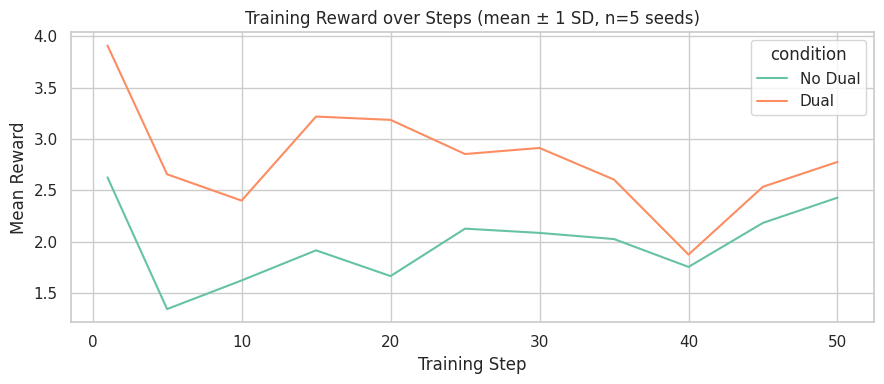

Saved: plot_reward_curves.pdf


In [15]:
sns.set_theme(style="whitegrid", palette="Set2")

# Plot 1 — Reward curves over training steps
fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(
    data=df_rewards, x="step", y="reward",
    hue="condition", errorbar="sd", ax=ax
)
ax.set_title("Training Reward over Steps (mean ± 1 SD, n=5 seeds)")
ax.set_xlabel("Training Step")
ax.set_ylabel("Mean Reward")
fig.tight_layout()
fig.savefig("plot_reward_curves.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_reward_curves.pdf")

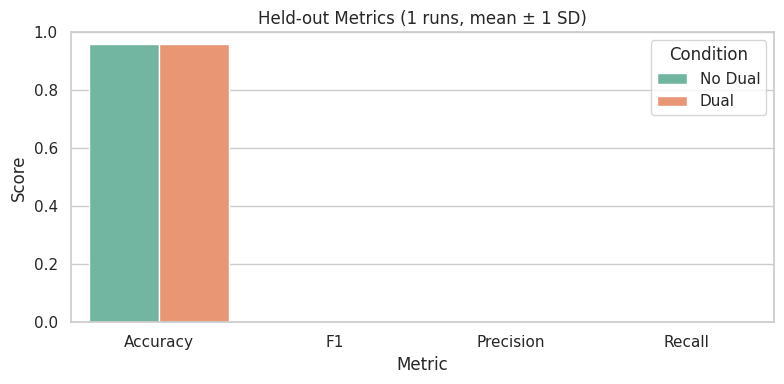

Saved: plot_metrics.pdf


In [16]:
# Plot 2 — Held-out classification metrics comparison
_METRIC_LABELS = {"accuracy": "Accuracy", "f1": "F1", "precision": "Precision", "recall": "Recall"}
df_plot = df_metrics.copy()
df_plot["Metric"] = df_plot["metric"].map(_METRIC_LABELS)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=df_plot, x="Metric", y="value",
    hue="condition", errorbar="sd", capsize=0.10, ax=ax
)
ax.set_title(f"Held-out Metrics ({N_RUNS} runs, mean ± 1 SD)")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(title="Condition")
fig.tight_layout()
fig.savefig("plot_metrics.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_metrics.pdf")


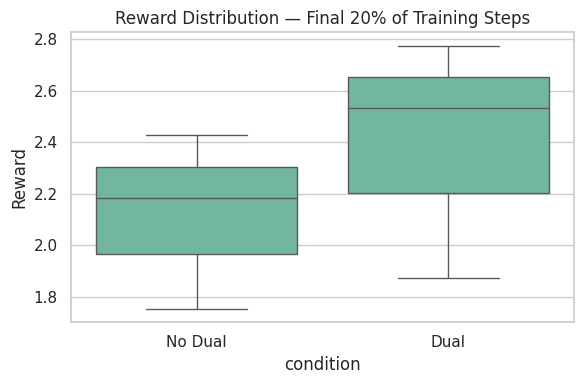

Saved: plot_reward_distribution.pdf


In [17]:
# Plot 3 — Reward distribution in the final 20% of training steps
max_step = df_rewards["step"].max()
final_mask = df_rewards["step"] >= max_step * 0.8
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(
    data=df_rewards[final_mask], x="condition", y="reward",
    ax=ax
)
ax.set_title("Reward Distribution — Final 20% of Training Steps")
ax.set_ylabel("Reward")
fig.tight_layout()
fig.savefig("plot_reward_distribution.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_reward_distribution.pdf")

In [18]:
print("All plots exported:")
print("  plot_reward_curves.pdf      — reward over training steps")
print("  plot_accuracy.pdf           — held-out accuracy per condition")
print("  plot_reward_distribution.pdf— reward distribution (final steps)")

All plots exported:
  plot_reward_curves.pdf      — reward over training steps
  plot_accuracy.pdf           — held-out accuracy per condition
  plot_reward_distribution.pdf— reward distribution (final steps)


In [19]:
!cp /content/*.pdf "${OUTPUT_DIR}"